# Transfer labeling with scANVI

In [1]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import anndata as ad
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


### Set paths

In [3]:
base_dir = Path('/home/workspace/projects/madv2')

adata_dir = base_dir / 'data/h5ad/03_scvi'
ref_data_dir = base_dir / 'data/h5ad/04_scanvi' # add the uninfected sample from Reina-Campos et al., 2025 to here

scvi_dir = base_dir / 'scvi'
scanvi_dir = base_dir / 'scanvi' # csv output
output_dir = base_dir / 'data/h5ad/04_scanvi' # h5ad output

scanvi_dir.mkdir(parents=True, exist_ok=True)
ref_data_dir.mkdir(parents= True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

### Read data

In [4]:
adata = sc.read_h5ad(os.path.join(adata_dir, 'madv2-scvi-leiden.h5ad'))
refdata = sc.read_h5ad(os.path.join(ref_data_dir, 'uninfected.h5ad')) # changed from adata/uninfected

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
refdata.obs_names_make_unique()

In [6]:
refdata.obs['batch'].value_counts()

batch
segmentation_SI1    242156
segmentation_SI2    191024
Name: count, dtype: int64

### Prepare adatas

In [7]:
print(refdata.layers)
print(adata.layers)

Layers with keys: raw
Layers with keys: counts, log1p, normalized_1e6


In [8]:
# restore raw counts, assign same name as query adata
refdata.layers['counts'] = refdata.layers['raw'].copy()  # Store raw counts
refdata.X = refdata.layers['counts'].copy()  # Set X to use raw counts

In [9]:
adata.X = adata.layers['counts'].copy()

In [10]:
adata.X[:5, :5].toarray()  # Convert and preview first 5x5 matrix elements

array([[0., 0., 1., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)

In [11]:
print(refdata.X[:5, :5])

[[5 0 0 1 0]
 [5 0 0 0 0]
 [4 0 0 0 1]
 [0 0 0 0 0]
 [0 0 0 0 1]]


In [12]:
# add sample_id for refdata
refdata.obs['sample_id'] = refdata.obs['batch']
refdata.obs.sample_id.value_counts()

sample_id
segmentation_SI1    242156
segmentation_SI2    191024
Name: count, dtype: int64

In [13]:
# add column up here for filtering later only on refdata
refdata.obs['ref_data'] = 'Yes'
adata.obs['ref_data'] = 'No'

## Gene alignment and concatenation

In [14]:
# Find the intersection of genes for integration
common_genes = list(set(adata.var_names) & set(refdata.var_names))
len(common_genes)

323

### Create subsets

In [15]:
# Create copies of the datasets, keeping only common genes
adata_subset = adata[:, common_genes].copy()
refdata_subset = refdata[:, common_genes].copy()

In [16]:
print(f"adata before subsetting: {adata.shape[1]}")
print(f"adata after subsetting: {adata_subset.shape[1]}")

print(f"refdata before subsetting: {refdata.shape[1]}")
print(f"refdata after subsetting: {refdata_subset.shape[1]}")

adata before subsetting: 480
adata after subsetting: 323
refdata before subsetting: 480
refdata after subsetting: 323


In [17]:
index_match = (adata_subset.var_names == refdata_subset.var_names).all()
print(f"adata.var_names match: {index_match}")

adata.var_names match: True


# Concatenate

In [18]:
print(adata_subset.obs.columns)
print(refdata_subset.obs.columns)

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample',
       'xenium_run_id', 'sample_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes',
       'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch',
       '_scvi_labels', 'leiden_scVI_1', 'ref_data'],
      dtype='object')
Index(['total_transcripts', 'nuclear_transcripts', 'cytoplasmic_transcripts',
       'nuclear_transcript_percentage', 'x', 'y', 'topic', 'batch',
       '_scvi_batch', '_scvi_labels', 'celltype_predicted', 'Subtype', 'Type',
       'Immunocentric_Type', 'Class', 'leiden', 'epit

In [19]:
# Concatenate datasets
adata_list = [adata_subset, refdata_subset]

adata_concat = ad.concat(adata_list, 
                  join="outer", # make sure it's outer
                  label = 'scanvi_batch',
                  index_unique="-")

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/anndata/_core/merge.py:1358: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [20]:
adata_concat # confirm number genes

AnnData object with n_obs × n_vars = 2254184 × 323
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample', 'xenium_run_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'ref_data', 'total_transcripts', 'nuclear_transcripts', 'cytoplasmic_transcripts', 'nuclear_transcript_percentage', 'x', 'y', 'topic', 'celltype_predicted', 'Subtype', 'Type', 'Immunocentric_Type', 'Class', 'leiden', 'epithelial_distance', 'crypt_villi_axis', 'epithelial_distance_clipped', 'reference_crypt_villi', 'villi_number'

In [21]:
adata_concat.obs.sample_id.value_counts()

sample_id
Hp_MAdV2_D3         536458
Hp_MAdV2_D12        452605
Hp_alone            452154
MAdV2_alone_D3      379787
segmentation_SI1    242156
segmentation_SI2    191024
Name: count, dtype: int64

### Perform filtering on concatenated adata

In [22]:
sc.pp.calculate_qc_metrics(adata_concat, percent_top=(10, 20, 50, 150), inplace=True) # adds total_counts metric for filtering

In [23]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 0.0, 1731.0


In [24]:
# or operator ensures that rows satisfying at least one condition are kept
# so if adata.obs.ref_data = No (study samples), then the cell is kept
# OR if adata.obs.ref_data = Yes AND the cell has acceptable total counts the row is also kept

adata_concat = adata_concat[
    (adata_concat.obs["ref_data"] == "No") |  # Keep all non-reference samples
    ((adata_concat.obs["ref_data"] == "Yes") &  # Apply total_counts filter only to reference samples
     (adata_concat.obs["total_counts"] > 20) & 
     (adata_concat.obs["total_counts"] < 800))
].copy()

In [25]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 6.0, 1731.0


# Examine Batch Effects

In [26]:
adata_concat.X[:5, :5].toarray()

array([[0., 0., 6., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 2., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [27]:
# Normalize and run PCA
sc.pp.normalize_total(adata_concat)
sc.pp.log1p(adata_concat)
sc.pp.pca(adata_concat)

# UMAP colored by sample_id
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)

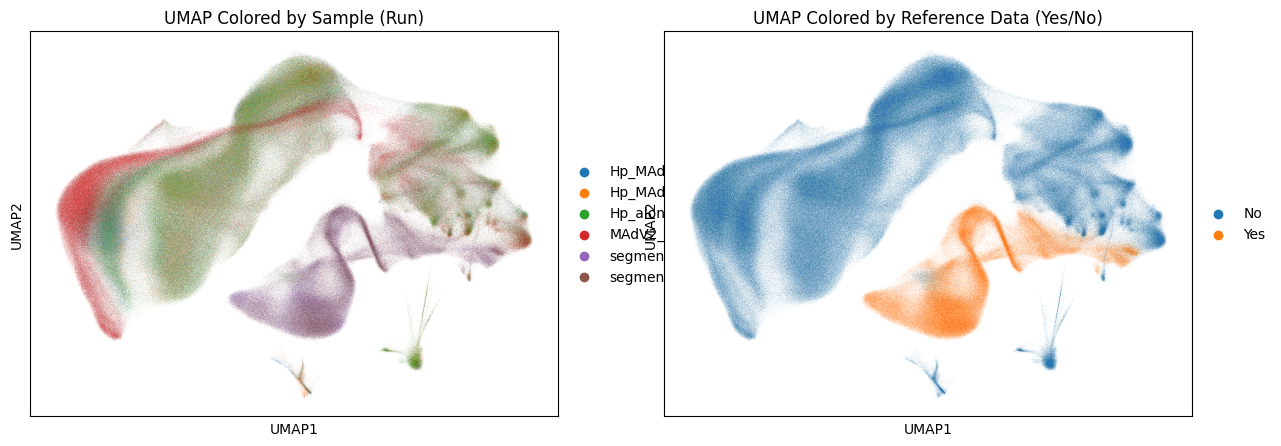

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot UMAP by sample_id
sc.pl.umap(adata_concat, color="sample_id", show=False, ax=axes[0])
axes[0].set_title("UMAP Colored by Sample (Run)")

# Plot UMAP by ref_data
sc.pl.umap(adata_concat, color="ref_data", show=False, ax=axes[1])
axes[1].set_title("UMAP Colored by Reference Data (Yes/No)")

plt.show()
plt.close()

## Train scVI model

In [29]:
# Check batch key
adata_concat.obs['sample_id'].value_counts()

sample_id
Hp_MAdV2_D3         536458
Hp_MAdV2_D12        452605
Hp_alone            452154
MAdV2_alone_D3      379787
segmentation_SI1    212817
segmentation_SI2    173709
Name: count, dtype: int64

In [30]:
scvi.model.SCVI.setup_anndata(
    adata_concat, 
    layer="counts", # use raw count data
    batch_key='ref_data', # biggest batch effect is panel
    categorical_covariate_keys = ['sample_id'] # inter-run variability as a covariate
)

model = scvi.model.SCVI(adata_concat,
                       n_layers = 2,
                       n_latent = 30)
print('starting model training')

model.train(early_stopping=True, 
            enable_progress_bar=True,
            accelerator = 'gpu'
           )

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


starting model training


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a

Epoch 4/4: 100%|██████████| 4/4 [12:46<00:00, 191.38s/it, v_num=1, train_loss_step=150, train_loss_epoch=149]

`Trainer.fit` stopped: `max_epochs=4` reached.


Epoch 4/4: 100%|██████████| 4/4 [12:46<00:00, 191.67s/it, v_num=1, train_loss_step=150, train_loss_epoch=149]


In [31]:
model.save(os.path.join(scvi_dir, '02_model') , prefix='02_label_transfer_')

In [32]:
SCVI_LATENT_KEY = "X_scVI_refalign"
adata_concat.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

### Compute neighbors graph and UMAP

In [33]:
# neighbors
sc.pp.neighbors(adata_concat, use_rep="X_scVI_refalign", key_added='neighbors_scvi_refalign')
sc.tl.umap(adata_concat, neighbors_key='neighbors_scvi_refalign')

### Export refaligned adata

In [34]:
# save umap dims to csv
umap_df = pd.DataFrame(adata_concat.obsm['X_umap'], index=adata_concat.obs_names, columns=['umap1', 'umap2'])
filename = os.path.join(scanvi_dir, 'adata_scvi_refalign_umap_coords.csv')
umap_df.to_csv(filename)

In [35]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

# Checkpoint

In [36]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
adata_concat = sc.read_h5ad(filename)
adata_concat

AnnData object with n_obs × n_vars = 2207530 × 323
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample', 'xenium_run_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'ref_data', 'total_transcripts', 'nuclear_transcripts', 'cytoplasmic_transcripts', 'nuclear_transcript_percentage', 'x', 'y', 'topic', 'celltype_predicted', 'Subtype', 'Type', 'Immunocentric_Type', 'Class', 'leiden', 'epithelial_distance', 'crypt_villi_axis', 'epithelial_distance_clipped', 'reference_crypt_villi', 'villi_number'

### Prep data for scANVI

In [37]:
adata_concat.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample',
       'xenium_run_id', 'sample_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes',
       'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch',
       '_scvi_labels', 'leiden_scVI_1', 'ref_data', 'total_transcripts',
       'nuclear_transcripts', 'cytoplasmic_transcripts',
       'nuclear_transcript_percentage', 'x', 'y', 'topic',
       'celltype_predicted', 'Subtype', 'Type', 'Immunocentric_Type', 'Class',
       'leiden', 'epithelial_distance', 'crypt_villi_axis',
       'epithelial_distan

In [38]:
# Add unknown category for original  samples
adata_concat.obs['Subtype'] = adata_concat.obs['Subtype'].cat.add_categories('Unknown')
adata_concat.obs = adata_concat.obs.fillna(value = {'Subtype': 'Unknown'})

In [39]:
adata_concat.obs['Subtype'].value_counts() # confirm that Subtype is the most granular

Subtype
Unknown                  1821004
Enterocyte_2              101934
Transit_Amplifying         50875
Early_Enterocyte           42665
Enterocyte_1               41525
Enterocyte_3               27311
Myofibroblast              18639
ILC                        14404
Fibroblast                 10355
Paneth                      9373
ISC                         8506
Macrophage                  7848
Monocyte                    5256
Goblet                      5075
MAIT                        4932
T-Cell gd                   4579
Enteroendocrine             4038
Resting Fibroblast          3451
B-Cell                      3061
Vascular Endothelial        2869
Cd4_T-Cell                  2807
Cd8_T-Cell_aa+              2569
Fibroblast_Pdgfra+          2342
Neuron                      2307
Fibroblast_Pdgfrb+          1746
Tuft                        1724
Lymphatic                   1594
Complement_Fibroblast       1353
cDC1                         903
Fibroblast_Ncam1             790
DC

Below is important for mapping labels in the unintegrated original adata

In [40]:
# Subset only query dataset (unlabeled before scANVI training)
query_cells = adata_concat.obs["Subtype"] == "Unknown"
query_cells.to_csv(os.path.join(scanvi_dir, 'query_cells-subtype.csv'))
query_cells

aaaaammh-1-0-0     True
aaaadboe-1-0-0     True
aaaadpcn-1-0-0     True
aaaaicab-1-0-0     True
aaaaindg-1-0-0     True
                  ...  
oiijgoon-1-1      False
oiikkjlg-1-1      False
oiiklekf-1-1      False
oiiknmmm-1-1      False
oiikphad-1-1      False
Name: Subtype, Length: 2207530, dtype: bool

In [41]:
# fix barcodes; suffix was added during concat
query_cells_copy = query_cells.copy()
query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])
query_cells_copy

aaaaammh-1-0     True
aaaadboe-1-0     True
aaaadpcn-1-0     True
aaaaicab-1-0     True
aaaaindg-1-0     True
                ...  
oiijgoon-1      False
oiikkjlg-1      False
oiiklekf-1      False
oiiknmmm-1      False
oiikphad-1      False
Name: Subtype, Length: 2207530, dtype: bool

## Run scANVI

In [42]:
# scanvi label transfer
scanvi_model = scvi.model.SCANVI.from_scvi_model(model, 
                                                 adata = adata_concat, 
                                                 unlabeled_category = 'Unknown', # Entries in labels_key to label
                                                 labels_key = 'Subtype') # Column to transfer labels from

scanvi_model.train(max_epochs=20, 
                   accelerator = 'gpu',
                   n_samples_per_label = None) # this is longer training because it's not subsampling

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


INFO     Training for 20 epochs.                                                                                   


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 20/20: 100%|██████████| 20/20 [2:33:02<00:00, 458.98s/it, v_num=1, train_loss_step=158, train_loss_epoch=145]  

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [2:33:02<00:00, 459.15s/it, v_num=1, train_loss_step=158, train_loss_epoch=145]


In [43]:
# save scANVI model
scanvi_model.save(os.path.join(scvi_dir, '03_model_scanvi') , prefix='03_madv2_scanvi_')

### Reference mapping step

In [44]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "scanvi_labels_xenium"

adata_concat.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata_concat)
adata_concat.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata_concat) # this fills out the labels

In [45]:
adata_concat.obs['scanvi_labels_xenium'].value_counts()

scanvi_labels_xenium
Transit_Amplifying       416569
Early_Enterocyte         373159
Enterocyte_2             316689
Enterocyte_1             236933
Enterocyte_3             196849
Myofibroblast            106521
ILC                      100569
Fibroblast                73529
Macrophage                54999
MAIT                      47541
Goblet                    43931
ISC                       33721
Monocyte                  29454
Paneth                    26976
Resting Fibroblast        23082
Enteroendocrine           23071
Fibroblast_Pdgfrb+        21258
Vascular Endothelial      18776
Lymphatic                 16260
Neuron                     8863
Tuft                       7468
Fibroblast_Pdgfra+         7152
T-Cell gd                  4589
B-Cell                     3511
Complement_Fibroblast      3406
Cd4_T-Cell                 2917
Cd8_T-Cell_aa+             2671
cDC1                       2417
DC2                        2078
Fibroblast_Ncam1           1679
NK-Cell            

In [46]:
filename = os.path.join(output_dir, 'adata_concat-scvi-scanvi-predictions.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

## Map query labels onto original adata

In [47]:
# re-read fresh adata with all the genes, this is the query
adata_query = sc.read_h5ad(os.path.join(adata_dir, 'madv2-scvi-leiden.h5ad'))
adata_query.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,pct_counts_in_top_10_genes,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_150_genes,doublet_scores,predicted_doublets,batch,_scvi_batch,_scvi_labels,leiden_scVI_1
aaaaammh-1-0,aaaaammh-1,3210.215576,677.109985,1445,0,0,0,0,0,1445.0,...,43.598616,61.937716,87.889273,100.0,0.032325,False,0,0,0,2
aaaadboe-1-0,aaaadboe-1,3181.928467,681.276794,680,0,0,1,0,0,680.0,...,38.970588,60.000000,87.794118,100.0,0.066776,False,0,0,0,2
aaaadpcn-1-0,aaaadpcn-1,3201.998779,678.006042,764,0,0,0,0,0,764.0,...,41.753927,63.219895,87.696335,100.0,0.018901,False,0,0,0,2
aaaaicab-1-0,aaaaicab-1,3163.702881,702.131958,175,0,0,0,0,0,175.0,...,53.142857,72.571429,98.285714,100.0,0.016019,False,0,0,0,2
aaaaindg-1-0,aaaaindg-1,3170.981201,703.017578,290,0,0,0,0,0,290.0,...,57.931034,76.896552,96.551724,100.0,0.020310,False,0,0,0,2


In [48]:
# create adata_labeled from adata_concat which has the labels
adata_labeled = adata_concat[adata_concat.obs['scanvi_batch'] == '0'].copy() # batch is stored as string

print(adata_labeled.obs['scanvi_batch'].value_counts())
print('')
print(adata_labeled.obs['sample_id'].value_counts())

scanvi_batch
0    1821004
Name: count, dtype: int64

sample_id
Hp_MAdV2_D3       536458
Hp_MAdV2_D12      452605
Hp_alone          452154
MAdV2_alone_D3    379787
Name: count, dtype: int64


In [49]:
# Remove suffix from labeled adata subset from adata_concat
adata_labeled.obs.index = adata_labeled.obs.index.astype(str)
adata_labeled.obs.index = adata_labeled.obs.index.str[:-2]
adata_labeled.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,villi_number,peyers,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,scanvi_batch,scanvi_labels_xenium
aaaaammh-1-0,aaaaammh-1,3210.215576,677.109985,1445.0,0.0,0.0,0.0,0.0,0.0,1206.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Enterocyte_3
aaaadboe-1-0,aaaadboe-1,3181.928467,681.276794,680.0,0.0,0.0,1.0,0.0,0.0,548.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Enterocyte_1
aaaadpcn-1-0,aaaadpcn-1,3201.998779,678.006042,764.0,0.0,0.0,0.0,0.0,0.0,641.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Enterocyte_3
aaaaicab-1-0,aaaaicab-1,3163.702881,702.131958,175.0,0.0,0.0,0.0,0.0,0.0,149.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Enterocyte_3
aaaaindg-1-0,aaaaindg-1,3170.981201,703.017578,290.0,0.0,0.0,0.0,0.0,0.0,263.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Enterocyte_3


In [50]:
# fix barcodes; suffix was added during concat
#query_cells_copy = query_cells.copy()
#query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])

In [51]:
query_cells_copy

aaaaammh-1-0     True
aaaadboe-1-0     True
aaaadpcn-1-0     True
aaaaicab-1-0     True
aaaaindg-1-0     True
                ...  
oiijgoon-1      False
oiikkjlg-1      False
oiiklekf-1      False
oiiknmmm-1      False
oiikphad-1      False
Name: Subtype, Length: 2207530, dtype: bool

In [52]:
query_cells_copy = query_cells_copy[query_cells_copy].index.tolist()
print(set(query_cells_copy).issubset(set(adata_labeled.obs.index)))  # Should return True
print(set(query_cells_copy).issubset(set(adata_query.obs.index)))  # Should return True

True
True


In [53]:
# Transfer predictions back to the original query dataset
adata_query.obs['scanvi_labels_xenium'] = adata_labeled.obs.loc[query_cells_copy, "scanvi_labels_xenium"]
adata_query.obs['scanvi_labels_xenium']

aaaaammh-1-0     Enterocyte_3
aaaadboe-1-0     Enterocyte_1
aaaadpcn-1-0     Enterocyte_3
aaaaicab-1-0     Enterocyte_3
aaaaindg-1-0     Enterocyte_3
                    ...      
oindheaa-1-3    Myofibroblast
oindidnp-1-3    Myofibroblast
oindlloi-1-3     Enterocyte_2
oindpldo-1-3    Myofibroblast
oineblcn-1-3              ILC
Name: scanvi_labels_xenium, Length: 1821004, dtype: category
Categories (34, object): ['B-Cell', 'Cd4_T-Cell', 'Cd8_T-Cell_aa+', 'Cd8_T-Cell_ab+', ..., 'Transit_Amplifying', 'Tuft', 'Vascular Endothelial', 'cDC1']

In [54]:
adata_query.obs["scanvi_labels_xenium"].value_counts()

scanvi_labels_xenium
Transit_Amplifying       365279
Early_Enterocyte         337400
Enterocyte_1             196558
Enterocyte_2             193529
Enterocyte_3             181684
Myofibroblast             86281
ILC                       85430
Fibroblast                65312
Macrophage                44444
MAIT                      42249
Goblet                    39161
Monocyte                  25375
ISC                       24701
Fibroblast_Pdgfrb+        19475
Enteroendocrine           19039
Resting Fibroblast        18841
Paneth                    18059
Vascular Endothelial      16190
Lymphatic                 14985
Neuron                     6892
Tuft                       5816
Fibroblast_Pdgfra+         5212
Complement_Fibroblast      2501
DC2                        1927
cDC1                       1900
Fibroblast_Ncam1           1481
NK-Cell                     346
B-Cell                      248
Cd4_T-Cell                  234
Eosinophil                  219
T-Cell gd          

## Export labeled adata

In [55]:
h5ad_path = os.path.join(output_dir, 'madv2-scanvi-labels.h5ad')
adata_query.write_h5ad(h5ad_path, compression='gzip')

print(h5ad_path)

/home/workspace/projects/madv2/data/h5ad/04_scanvi/madv2-scanvi-labels.h5ad


## Session info

In [56]:
print('active IDE: sc-spatial-gpu')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
